# Home Credit Default Risk

Ноутбук с базовой загрузкой данных, feature engineering и сравнением baseline-моделей.


## Data Loading

Read the main application table and the base external credit history table.


In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import re

In [155]:
train = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')  # external credit history

## Bureau

Агрегация признаков по внешней кредитной истории клиента.


In [156]:
bureau['ACTIVE_CREDIT'] = (bureau['DAYS_CREDIT_ENDDATE'] > 0).astype(int)
bureau['PAST_ENDDATE'] = (bureau['DAYS_CREDIT_ENDDATE'] < 0).astype(int)
bureau['EARLY_CLOSE'] = (bureau['DAYS_ENDDATE_FACT'] > bureau['DAYS_CREDIT_ENDDATE']).astype(int)

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
    CREDIT_COUNT=('SK_ID_BUREAU', 'count'),
    CREDIT_MEAN=('AMT_CREDIT_SUM', 'mean'),
    CREDIT_MAX=('AMT_CREDIT_SUM', 'max'),

    DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    DAYS_CREDIT_MOST_RECENT=('DAYS_CREDIT', 'max'),
    DAYS_CREDIT_OLDEST=('DAYS_CREDIT', 'min'),

    CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    CREDIT_DAY_OVERDUE_MIN=('CREDIT_DAY_OVERDUE', 'min'),
    CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    CREDIT_DAY_OVERDUE_SUM=('CREDIT_DAY_OVERDUE', 'sum'),

    DAYS_CREDIT_ENDDATE_MAX=('DAYS_CREDIT_ENDDATE', 'max'),
    DAYS_CREDIT_ENDDATE_MIN=('DAYS_CREDIT_ENDDATE', 'min'),
    DAYS_CREDIT_ENDDATE_MEAN=('DAYS_CREDIT_ENDDATE', 'mean'),
    DAYS_CREDIT_ENDDATE_SUM=('DAYS_CREDIT_ENDDATE', 'sum'),

    DAYS_ENDDATE_FACT_MEAN=('DAYS_ENDDATE_FACT', 'mean'),

    ACTIVE_CREDIT_SUM=('ACTIVE_CREDIT', 'sum'),
    ACTIVE_CREDIT_MEAN=('ACTIVE_CREDIT', 'mean'),

    PAST_ENDDATE_SUM=('PAST_ENDDATE', 'sum'),
    PAST_ENDDATE_MEAN=('PAST_ENDDATE', 'mean'),

    EARLY_CLOSE_SUM=('EARLY_CLOSE', 'sum'),
    EARLY_CLOSE_MEAN=('EARLY_CLOSE', 'mean')
).reset_index()
type_credit = bureau.groupby(['SK_ID_CURR', 'CREDIT_TYPE']).size().unstack(fill_value=0).reset_index()
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')
train = train.merge(type_credit, on='SK_ID_CURR', how='left')

## Bureau Balance

Агрегация месячных статусов и объединение с `bureau`.


In [157]:
bb = pd.read_csv('bureau_balance.csv')
bb_agg = bb.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': ['min', 'max', 'count']
})
bb['status_to_num'] = bb['STATUS'].replace({
    'C': 0,
    'X': 0
}).astype(int)
status_agg = bb.groupby('SK_ID_BUREAU')['status_to_num'].agg([
    'max',
    'mean',
    'sum'
])
bb['is_bad'] = bb['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)
bad_agg = bb.groupby('SK_ID_BUREAU')['is_bad'].mean()
bb_sorted = bb.sort_values('MONTHS_BALANCE')


In [158]:
bb_agg.columns = ['bb_min', 'bb_max', 'bb_count']
status_agg.columns = ['bb_status_max', 'bb_status_mean', 'bb_status_sum']
bad_agg = bad_agg.rename('bb_bad_ratio')
bb_features = (
    bb_agg
    .join(status_agg)
    .join(bad_agg)
).reset_index()


In [159]:
bureau_full = bureau.merge(bb_features, on='SK_ID_BUREAU', how='left')
bureau_bb_agg = bureau_full.groupby('SK_ID_CURR').agg(
    BB_MIN_MIN=('bb_min', 'min'),
    BB_MAX_MAX=('bb_max', 'max'),
    BB_COUNT_MEAN=('bb_count', 'mean'),
    BB_COUNT_SUM=('bb_count', 'sum'),

    BB_STATUS_MAX_MAX=('bb_status_max', 'max'),
    BB_STATUS_MEAN_MEAN=('bb_status_mean', 'mean'),
    BB_STATUS_SUM_SUM=('bb_status_sum', 'sum'),

    BB_BAD_RATIO_MEAN=('bb_bad_ratio', 'mean'),
    BB_BAD_RATIO_MAX=('bb_bad_ratio', 'max')
).reset_index()

In [160]:
train = train.merge(bureau_bb_agg, on='SK_ID_CURR', how='left')

## Credit Card Balance

Подготовка агрегированных признаков по кредитным картам.


In [161]:
credit_card_balance = pd.read_csv('credit_card_balance.csv')
credit_card_balance['balance_to_limit'] = (
        credit_card_balance['AMT_BALANCE'] /
        credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
)
credit_card_balance['payment_to_min'] = credit_card_balance['AMT_PAYMENT_CURRENT'] / credit_card_balance[
    'AMT_INST_MIN_REGULARITY'].replace(0, np.nan)
credit_card_balance['payment_to_balance'] = credit_card_balance['AMT_PAYMENT_CURRENT'] / credit_card_balance[
    'AMT_BALANCE'].replace(0, np.nan)
credit_card_balance['drawings_to_limit'] = credit_card_balance['AMT_DRAWINGS_CURRENT'] / credit_card_balance[
    'AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc_agg = credit_card_balance.groupby('SK_ID_CURR').agg(
    balance_to_limit_mean=('balance_to_limit', 'mean'),
    balance_to_limit_max=('balance_to_limit', 'max'),
    dpd_mean=('SK_DPD', 'mean'),
    dpd_max=('SK_DPD', 'max'),
    payment_to_min_mean=('payment_to_min', 'mean'),
    payment_to_min_max=('payment_to_min', 'max'),
    payment_to_balance_mean=('payment_to_balance', 'mean'),
    payment_to_balance_max=('payment_to_balance', 'max'),
    drawings_to_limit_mean=('drawings_to_limit', 'mean'),
    drawings_to_limit_max=('drawings_to_limit', 'max')
).reset_index()
train = train.merge(cc_agg, on='SK_ID_CURR', how='left')

In [162]:
cc_features = ['balance_to_limit_mean', 'balance_to_limit_max', 'dpd_mean', 'dpd_max', 'payment_to_min_mean',
               'payment_to_min_max', 'payment_to_balance_mean', 'payment_to_balance_max',
               'drawings_to_limit_mean', 'drawings_to_limit_max']
train[cc_features] = train[cc_features].fillna(0)
train['has_bureau'] = (train['BB_COUNT_MEAN'] > 0).astype(int)
bb_cols = [col for col in train.columns if col.startswith('BB_')]
train[bb_cols] = train[bb_cols].fillna(0)

## Обработка пропусков и подготовка признаков

Заполнение пропусков и финализация набора признаков перед моделированием.


In [163]:
few_passes = ['DAYS_LAST_PHONE_CHANGE',
              'CNT_FAM_MEMBERS',
              'AMT_ANNUITY',
              'AMT_GOODS_PRICE']
train[few_passes] = train[few_passes].fillna(train[few_passes].mean())
social_columns = ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
                  'DEF_60_CNT_SOCIAL_CIRCLE']
train[social_columns] = train[social_columns].fillna(0)
amt_req = [col for col in train.columns if col.startswith('AMT_REQ_CREDIT_BUREAU')]
for i in range(len(amt_req)):
    train[f'have_checked_req_credit_{1}'] = (train[amt_req[i]] > 0).astype(int)
train[amt_req] = train[amt_req].fillna(0)

In [164]:
ext_sour = [col for col in train.columns if col.startswith('EXT_SOURCE_')]
for ext in ext_sour:
    train[ext] = train[ext].fillna(train[ext].mean())
past_end = [col for col in train.columns if col.startswith('PAST_END')]
early_close = [col for col in train.columns if col.startswith('EARLY_CLOSE')]
credit_cols = [
    'CREDIT_COUNT', 'CREDIT_MEAN', 'CREDIT_MAX',
    'ACTIVE_CREDIT_SUM', 'ACTIVE_CREDIT_MEAN',
    'CREDIT_DAY_OVERDUE_SUM', 'CREDIT_DAY_OVERDUE_MAX',
    'CREDIT_DAY_OVERDUE_MIN', 'CREDIT_DAY_OVERDUE_MEAN',
    'DAYS_CREDIT_ENDDATE_MIN', 'DAYS_CREDIT_ENDDATE_MAX',
    'DAYS_CREDIT_ENDDATE_MEAN', 'DAYS_ENDDATE_FACT_MEAN'
]
bureau_features = [
    'CREDIT_SUM',
    'DAYS_CREDIT_MOST_RECENT',
    'DAYS_CREDIT_MEAN',
    'DAYS_CREDIT_OLDEST',
    'DAYS_CREDIT_ENDDATE_SUM'
]
train['OWN_CAR_AGE'] = train['OWN_CAR_AGE'].fillna(0)
train[credit_cols] = train[credit_cols].fillna(0)
train[bureau_features] = train[bureau_features].fillna(0)
for past in past_end:
    train[past] = train[past].fillna(0)
for early in early_close:
    train[early] = train[early].fillna(0)

In [165]:
categorical = [
    'NAME_TYPE_SUITE',
    'OCCUPATION_TYPE',
    'EMERGENCYSTATE_MODE',
    'HOUSETYPE_MODE',
    'WALLSMATERIAL_MODE',
    'FONDKAPREMONT_MODE'
]
loan_types = [
    'Another type of loan',
    'Car loan',
    'Loan for business development',
    'Consumer credit',
    'Credit card',
    'Interbank credit',
    'Loan for the purchase of equipment',
    'Loan for purchase of shares (margin lending)',
    'Loan for working capital replenishment',
    'Cash loan (non-earmarked)',
    'Real estate loan',
    'Mortgage',
    'Mobile operator loan',
    'Unknown type of loan',
    'Microloan'
]
housing = [
    'TOTALAREA_MODE',

    'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE',

    'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE',
    'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE',

    'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
    'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE',

    'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE',
    'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE',

    'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE',
    'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE',
    'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE',

    'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE',
    'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE'
]
train[categorical] = train[categorical].fillna('Unknown')
train[loan_types] = train[loan_types].fillna(0)
train[housing] = train[housing].fillna(-1)

In [166]:
train.isnull().sum()



SK_ID_CURR                                      0
TARGET                                          0
NAME_CONTRACT_TYPE                              0
CODE_GENDER                                     0
FLAG_OWN_CAR                                    0
FLAG_OWN_REALTY                                 0
CNT_CHILDREN                                    0
AMT_INCOME_TOTAL                                0
AMT_CREDIT                                      0
AMT_ANNUITY                                     0
AMT_GOODS_PRICE                                 0
NAME_TYPE_SUITE                                 0
NAME_INCOME_TYPE                                0
NAME_EDUCATION_TYPE                             0
NAME_FAMILY_STATUS                              0
NAME_HOUSING_TYPE                               0
REGION_POPULATION_RELATIVE                      0
DAYS_BIRTH                                      0
DAYS_EMPLOYED                                   0
DAYS_REGISTRATION                               0


## Первичный EDA

Быстрая проверка распределения целевой переменной `TARGET`.


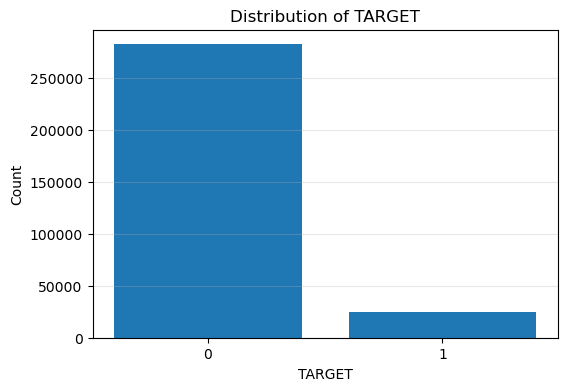

In [167]:
target_counts = train['TARGET'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title('Distribution of TARGET')
plt.xlabel('TARGET')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Подготовка выборок

Разделение данных и one-hot encoding категориальных признаков.


In [168]:
Y = train['TARGET']
X = train.drop('TARGET', axis=1)

cat_cols = X.select_dtypes(include=['object']).columns

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

x_train_ohe = ohe.fit_transform(x_train[cat_cols])
x_train_ohe_df = pd.DataFrame(
    x_train_ohe,
    columns=ohe.get_feature_names_out(cat_cols),
    index=x_train.index
)

x_test_ohe = ohe.transform(x_test[cat_cols])
x_test_ohe_df = pd.DataFrame(
    x_test_ohe,
    columns=ohe.get_feature_names_out(cat_cols),
    index=x_test.index
)

x_train = x_train.drop(columns=cat_cols)
x_test = x_test.drop(columns=cat_cols)

x_train = pd.concat([x_train, x_train_ohe_df], axis=1)
x_test = pd.concat([x_test, x_test_ohe_df], axis=1)

print(x_train.shape, x_test.shape)


(246008, 309) (61503, 309)


## Обучение и оценка моделей

Сравнение baseline-моделей по ROC-AUC и PR-AUC.


In [169]:
models = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000, verbose=False),
        'Scaled': True
    },
    'LightGBM': {
        'model': LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42),
        'Scaled': False

    }
}


In [170]:
def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', str(col)).strip('_')
        for col in df.columns
    ]
    return df

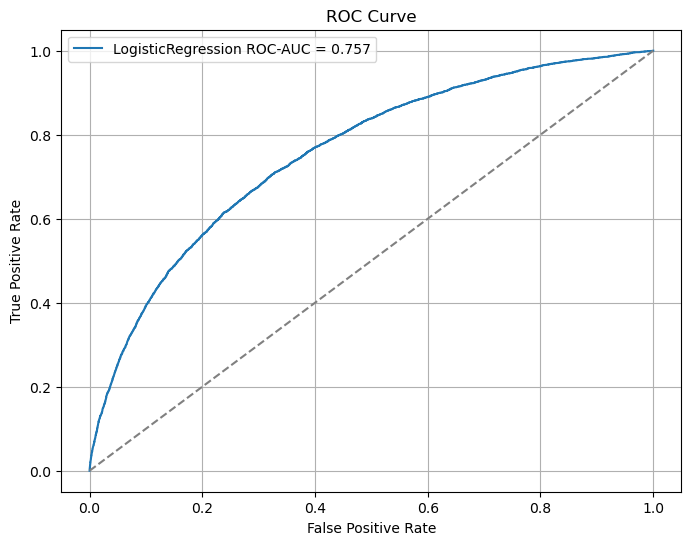

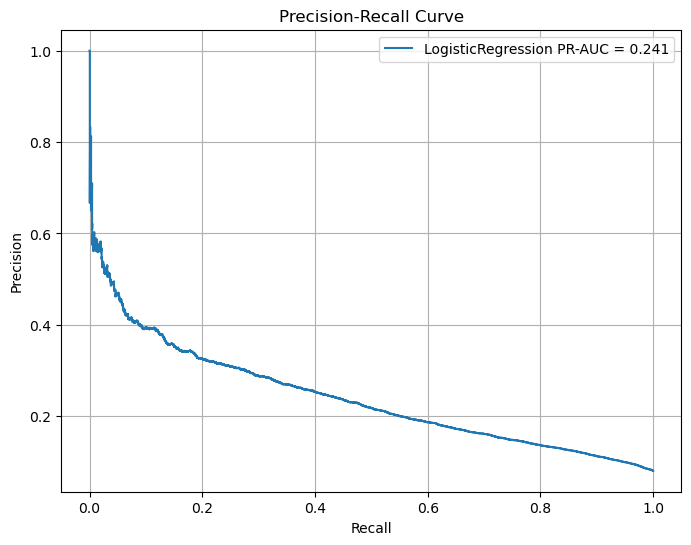

ROC-AUC_LogisticRegression: 0.756748
PR-AUC_LogisticRegression: 0.240608
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20220
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 293
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


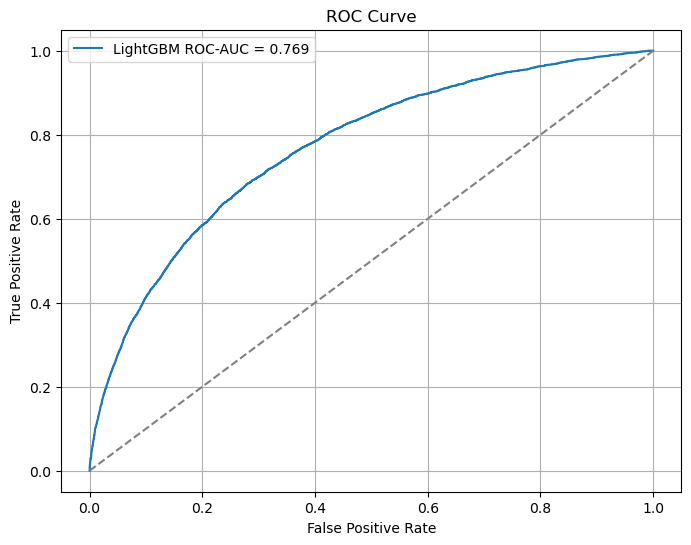

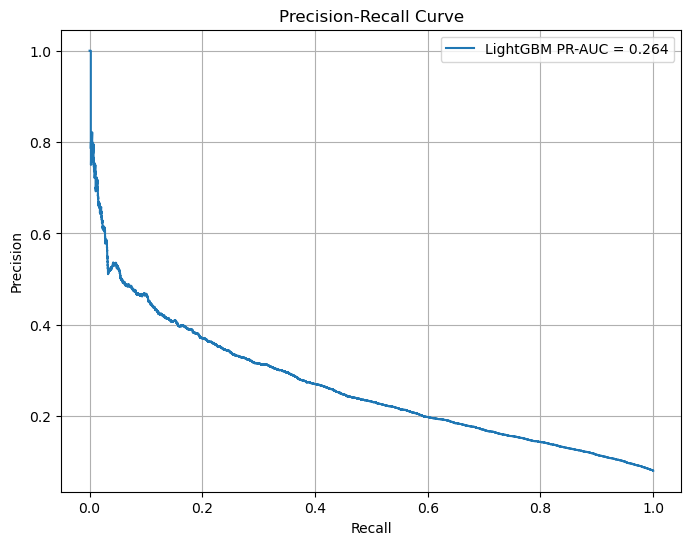

ROC-AUC_LightGBM: 0.768617
PR-AUC_LightGBM: 0.264154


In [171]:
results_baseline = {}

x_train = clean_feature_names(x_train)
x_test = clean_feature_names(x_test)
for name, info in models.items():
    model = info['model']
    use_scaler = info['Scaled']

    x_train_model = x_train.copy()
    x_test_model = x_test.copy()

    if use_scaler:
        scaler = StandardScaler()
        x_train_model = scaler.fit_transform(x_train_model)
        x_test_model = scaler.transform(x_test_model)

    model.fit(x_train_model, y_train)
    y_pred_proba = model.predict_proba(x_test_model)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    results[name] = {'ROC-AUC': roc_auc, 'PR-AUC': pr_auc}

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{name} ROC-AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'{name} PR-AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f'ROC-AUC_{name}: {roc_auc:.6f}')
    print(f'PR-AUC_{name}: {pr_auc:.6f}')


In [179]:
LightGBM = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
cv_scores = cross_val_score(LightGBM, x_train, y_train, cv=5, scoring='average_precision')
print(f'average_precision_mean нашей Baseline: {cv_scores.mean()}')

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.189556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20147
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 291
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.174730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20155
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 292
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[Lig

application

In [184]:
X_new_add_new_features = X.copy()
X_new_add_new_features['credit_income_credit'] = X_new_add_new_features['AMT_CREDIT'] / X_new_add_new_features[
    'AMT_INCOME_TOTAL']
X_new_add_new_features['annuity_to_income'] = X_new_add_new_features['AMT_ANNUITY'] / X_new_add_new_features[
    'AMT_INCOME_TOTAL']
X_new_add_new_features['income_for_person'] = X_new_add_new_features['AMT_INCOME_TOTAL'] / X_new_add_new_features[
    'CNT_FAM_MEMBERS']
train['EXT_SOURCE_MEAN'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
train['EXT_SOURCE_MAX'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
train['EXT_SOURCE_MAX'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
train['EXT_SOURCE_MAX'] = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

C:\Users\myska\AppData\Local\Temp\ipykernel_5048\294029681.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['EXT_SOURCE_MAX'] = train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].max(axis=1)


In [187]:
ins_pay = pd.read_csv('installments_payments.csv')

ins_pay['days_late'] = ins_pay['DAYS_ENTRY_PAYMENT'] - ins_pay['DAYS_INSTALMENT']
ins_pay['late_flag'] = (ins_pay['days_late'] > 0).astype(int)
ins_pay['pay_diff'] = ins_pay['AMT_PAYMENT'] - ins_pay['AMT_INSTALMENT']
ins_pay['pay_ratio'] = ins_pay['AMT_PAYMENT'] / ins_pay['AMT_INSTALMENT'].replace(0, np.nan)
ins_pay['early_flag'] = (ins_pay['days_late'] < 0).astype(int)
ins_pay['underpaid_flag'] = (ins_pay['pay_diff'] < 0).astype(int)
ins_pay['overpaid_flag'] = (ins_pay['pay_diff'] > 0).astype(int)
ins_pay['severe_late_30'] = (ins_pay['days_late'] > 30).astype(int)
ins_agg = ins_pay.groupby('SK_ID_CURR').agg(
    INS_DAYS_LATE_MEAN=('days_late', 'mean'),
    INS_DAYS_LATE_MAX=('days_late', 'max'),
    INS_LATE_RATIO=('late_flag', 'mean'),
    INS_LATE_COUNT=('late_flag', 'sum'),
    INS_EARLY_RATIO=('early_flag', 'mean'),
    INS_PAY_DIFF_MEAN=('pay_diff', 'mean'),
    INS_PAY_DIFF_MIN=('pay_diff', 'min'),
    INS_PAY_RATIO_MEAN=('pay_ratio', 'mean'),
    INS_PAY_RATIO_MIN=('pay_ratio', 'min'),
    INS_UNDERPAID_RATIO=('underpaid_flag', 'mean'),
    INS_SEVERE_LATE_30_RATIO=('severe_late_30', 'mean'),
    INS_AMT_PAYMENT_SUM=('AMT_PAYMENT', 'sum'),
    INS_AMT_INSTALMENT_SUM=('AMT_INSTALMENT', 'sum'),
    INS_RECORD_COUNT=('SK_ID_PREV', 'count'),
    INS_PREV_LOAN_NUNIQUE=('SK_ID_PREV', 'nunique')
).reset_index()
X_new_add_new_features = X_new_add_new_features.merge(ins_agg, on='SK_ID_CURR', how='left')

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.823137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20960
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 296
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


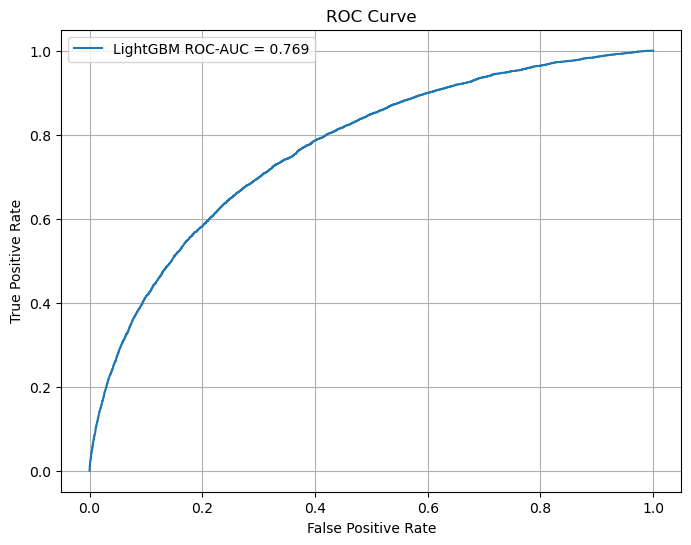

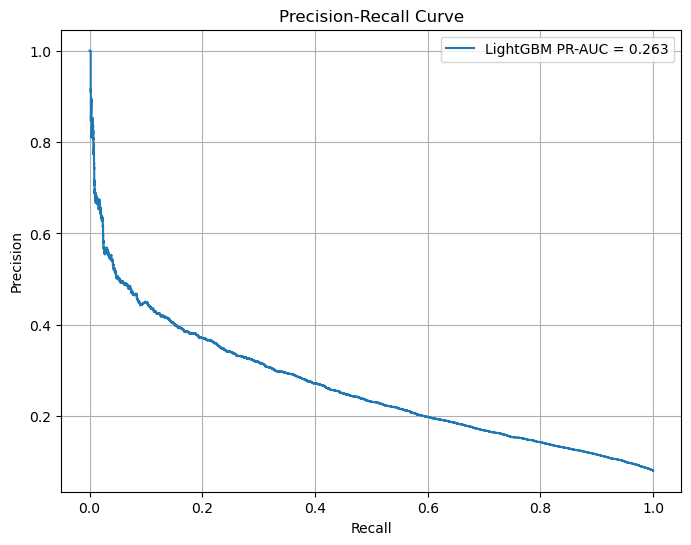

ROC-AUC_LightGBM: 0.768549
PR-AUC_LightGBM: 0.263260


In [196]:

LightGBM = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
x_train, x_test, y_train, y_test = train_test_split(X_new_add_new_features, Y, test_size=0.2, random_state=42,
                                                    stratify=Y)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

x_train_ohe = ohe.fit_transform(x_train[cat_cols])
x_train_ohe_df = pd.DataFrame(
    x_train_ohe,
    columns=ohe.get_feature_names_out(cat_cols),
    index=x_train.index
)

x_test_ohe = ohe.transform(x_test[cat_cols])
x_test_ohe_df = pd.DataFrame(
    x_test_ohe,
    columns=ohe.get_feature_names_out(cat_cols),
    index=x_test.index
)

x_train = x_train.drop(columns=cat_cols)
x_test = x_test.drop(columns=cat_cols)

x_train = pd.concat([x_train, x_train_ohe_df], axis=1)
x_test = pd.concat([x_test, x_test_ohe_df], axis=1)
x_train = clean_feature_names(x_train)
x_test = clean_feature_names(x_test)
LightGBM.fit(x_train, y_train)
y_pred_proba = LightGBM.predict_proba(x_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{name} ROC-AUC = {roc_auc:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'{name} PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()
print(f'ROC-AUC_LightGBM: {roc_auc:.6f}')
print(f'PR-AUC_LightGBM: {pr_auc:.6f}')

In [197]:
LightGBM = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
cv_scores = cross_val_score(LightGBM, x_train, y_train, cv=5, scoring='average_precision')
print(f'average_precision_mean нашей Baseline: {cv_scores.mean()}')

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.095909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20885
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 294
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.106243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20891
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 295
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[Lig